# Exploratory Data Analysis (EDA)
## Visualising Global Well-Being: Linking Economic Capacity, Health Outcomes, and Happiness

**Purpose:** Download, inspect, clean, merge, and explore the three project datasets.



In [7]:

%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 60)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 6)
print("Libraries imported")

Libraries imported


## Section 2: Load Raw Datasets
Raw CSVs are stored in `raw_data/` (World Bank, WHO, Happiness Report from Kaggle).

In [8]:
# Ensure CWD is the notebook's directory (repo root)
import pathlib
_nb_dir = pathlib.Path(__file__).parent if '__file__' in dir() else pathlib.Path.cwd()
# In VS Code / Jupyter the notebook path is available via __vsc_ipynb_file__
if '__vsc_ipynb_file__' in dir():
    _nb_dir = pathlib.Path(__vsc_ipynb_file__).parent
os.chdir(_nb_dir)
print(f"Working directory: {os.getcwd()}")

# Paths relative to repo root
path_ds1 = os.path.join('raw_data', 'world_bank')
path_ds2 = os.path.join('raw_data', 'who')
path_ds3 = os.path.join('raw_data', 'happiness')

for name, path in [("DS1 (World Bank)", path_ds1), ("DS2 (WHO)", path_ds2), ("DS3 (Happiness)", path_ds3)]:
    print(f"{name}: {path}")
    print(f"  Files: {os.listdir(path)}")

Working directory: c:\Projects\F21DV-fork-temp
DS1 (World Bank): raw_data\world_bank
  Files: ['world_bank_development_indicators.csv']
DS2 (WHO): raw_data\who
  Files: ['Life Expectancy Data.csv']
DS3 (Happiness): raw_data\happiness
  Files: ['2015.csv', '2016.csv', '2017.csv', '2018.csv', '2019.csv']


## Section 3: Load Datasets into DataFrames
DS3 (Happiness) has different column names per year â€” we standardize them.

In [9]:
# DS1: World Bank
df_wb = pd.read_csv(os.path.join(path_ds1, 'world_bank_development_indicators.csv'))
df_wb['Year'] = pd.to_datetime(df_wb['date']).dt.year
df_wb.rename(columns={'country': 'Country'}, inplace=True)

# DS2: WHO Life Expectancy
df_who = pd.read_csv(os.path.join(path_ds2, 'Life Expectancy Data.csv'))

# DS3: World Happiness (standardize column names across years)
happiness_frames = []
for year_file in sorted(os.listdir(path_ds3)):
    if not year_file.endswith('.csv'): continue
    year = int(year_file.replace('.csv', ''))
    df_temp = pd.read_csv(os.path.join(path_ds3, year_file))
    col_map = {}
    for col in df_temp.columns:
        cl = col.lower().replace('.', ' ').replace('_', ' ').strip()
        if 'country' in cl: col_map[col] = 'Country'
        elif 'happiness score' in cl or cl == 'score': col_map[col] = 'Happiness Score'
        elif 'happiness rank' in cl or 'overall rank' in cl: col_map[col] = 'Happiness Rank'
        elif 'gdp' in cl or 'economy' in cl: col_map[col] = 'GDP per Capita'
        elif 'family' in cl or 'social support' in cl: col_map[col] = 'Social Support'
        elif 'health' in cl or 'life expectancy' in cl: col_map[col] = 'Healthy Life Expectancy'
        elif 'freedom' in cl: col_map[col] = 'Freedom'
        elif 'generosity' in cl: col_map[col] = 'Generosity'
        elif 'trust' in cl or 'corruption' in cl: col_map[col] = 'Perceptions of Corruption'
        elif 'region' in cl: col_map[col] = 'Region'
    df_temp = df_temp.rename(columns=col_map)
    df_temp['Year'] = year
    happiness_frames.append(df_temp)
df_happiness = pd.concat(happiness_frames, ignore_index=True)
std_cols = ['Country','Year','Happiness Rank','Happiness Score','GDP per Capita',
            'Social Support','Healthy Life Expectancy','Freedom','Generosity',
            'Perceptions of Corruption','Region']
df_happiness = df_happiness[[c for c in std_cols if c in df_happiness.columns]]

print(f"DS1 (World Bank):  {df_wb.shape}")
print(f"DS2 (WHO):         {df_who.shape}")
print(f"DS3 (Happiness):   {df_happiness.shape}")

DS1 (World Bank):  (17272, 51)
DS2 (WHO):         (2938, 22)
DS3 (Happiness):   (782, 11)


## Section 4: Preview & Inspect the Data

In [10]:
print("=" * 60)
print("DS1: WORLD BANK DEVELOPMENT INDICATORS")
print("=" * 60)
print(f"Shape: {df_wb.shape[0]} rows x {df_wb.shape[1]} columns")
print(f"Year range: {df_wb['Year'].min()} - {df_wb['Year'].max()}")
print(f"Countries: {df_wb['Country'].nunique()}")
print(f"\nColumn names:\n{list(df_wb.columns)}")
print(f"\nFirst 3 rows:")
display(df_wb.head(3))

DS1: WORLD BANK DEVELOPMENT INDICATORS
Shape: 17272 rows x 51 columns
Year range: 1960 - 2023
Countries: 274

Column names:
['Country', 'date', 'agricultural_land%', 'forest_land%', 'land_area', 'avg_precipitation', 'trade_in_services%', 'control_of_corruption_estimate', 'control_of_corruption_std', 'access_to_electricity%', 'renewvable_energy_consumption%', 'electric_power_consumption', 'CO2_emisions', 'other_greenhouse_emisions', 'population_density', 'inflation_annual%', 'real_interest_rate', 'risk_premium_on_lending', 'research_and_development_expenditure%', 'central_goverment_debt%', 'tax_revenue%', 'expense%', 'goverment_effectiveness_estimate', 'goverment_effectiveness_std', 'human_capital_index', 'doing_business', 'time_to_get_operation_license', 'statistical_performance_indicators', 'individuals_using_internet%', 'logistic_performance_index', 'military_expenditure%', 'GDP_current_US', 'political_stability_estimate', 'political_stability_std', 'rule_of_law_estimate', 'rule_of_l

,Country,date,agricultural_land%,forest_land%,land_area,avg_precipitation,trade_in_services%,control_of_corruption_estimate,control_of_corruption_std,access_to_electricity%,renewvable_energy_consumption%,electric_power_consumption,CO2_emisions,other_greenhouse_emisions,population_density,inflation_annual%,real_interest_rate,risk_premium_on_lending,research_and_development_expenditure%,central_goverment_debt%,tax_revenue%,expense%,goverment_effectiveness_estimate,goverment_effectiveness_std,human_capital_index,doing_business,time_to_get_operation_license,statistical_performance_indicators,individuals_using_internet%,logistic_performance_index,military_expenditure%,GDP_current_US,political_stability_estimate,political_stability_std,rule_of_law_estimate,rule_of_law_std,regulatory_quality_estimate,regulatory_quality_std,government_expenditure_on_education%,government_health_expenditure%,multidimensional_poverty_headcount_ratio%,gini_index,birth_rate,death_rate,life_expectancy_at_birth,population,rural_population,voice_and_accountability_estimate,voice_and_accountability_std,intentional_homicides,Year
0,Afghanistan,1960-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.377778e+08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,50.340,31.921,32.535,8622466.0,7898093.0,NaN,NaN,NaN,1960
1,Afghanistan,1961-01-01,57.878356,NaN,652230.0,327.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.477056,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.488889e+08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,50.443,31.349,33.068,8790140.0,8026804.0,NaN,NaN,NaN,1961
2,Afghanistan,1962-01-01,57.955016,NaN,652230.0,327.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.751356,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.466667e+08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,50.570,30.845,33.547,8969047.0,8163985.0,NaN,NaN,NaN,1962


In [11]:
print("=" * 60)
print("DS2: WHO LIFE EXPECTANCY")
print("=" * 60)
print(f"Shape: {df_who.shape[0]} rows x {df_who.shape[1]} columns")
print(f"Year range: {df_who['Year'].min()} - {df_who['Year'].max()}")
print(f"Countries: {df_who['Country'].nunique()}")
display(df_who.head(3))

DS2: WHO LIFE EXPECTANCY
Shape: 2938 rows x 22 columns
Year range: 2000 - 2015
Countries: 193


,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,19.1,83,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,18.6,86,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,18.1,89,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9


In [12]:
print("=" * 60)
print("DS3: WORLD HAPPINESS REPORT (COMBINED)")
print("=" * 60)
print(f"Shape: {df_happiness.shape[0]} rows x {df_happiness.shape[1]} columns")
print(f"Year range: {df_happiness['Year'].min()} - {df_happiness['Year'].max()}")
print(f"Countries: {df_happiness['Country'].nunique()}")
print(f"\nRecords per year:\n{df_happiness['Year'].value_counts().sort_index()}")
display(df_happiness.head(3))

DS3: WORLD HAPPINESS REPORT (COMBINED)
Shape: 782 rows x 11 columns
Year range: 2015 - 2019
Countries: 170

Records per year:
Year
2015    158
2016    157
2017    155
2018    156
2019    156
Name: count, dtype: int64


,Country,Year,Happiness Rank,Happiness Score,GDP per Capita,Social Support,Healthy Life Expectancy,Freedom,Generosity,Perceptions of Corruption,Region
0,Switzerland,2015,1,7.587,1.39651,1.34951,0.94143,0.66557,0.29678,0.41978,Western Europe
1,Iceland,2015,2,7.561,1.30232,1.40223,0.94784,0.62877,0.43630,0.14145,Western Europe
2,Denmark,2015,3,7.527,1.32548,1.36058,0.87464,0.64938,0.34139,0.48357,Western Europe


## Section 5: Summary Statistics

In [13]:
# Key World Bank columns (actual column names from the dataset)
key_wb_cols = [c for c in ['GDP_current_US','life_expectancy_at_birth','population',
    'CO2_emisions','access_to_electricity%','individuals_using_internet%',
    'gini_index','human_capital_index'] if c in df_wb.columns]

print("DS1: World Bank - Key Indicators")
display(df_wb[key_wb_cols].describe().round(2))
print("\nDS2: WHO Life Expectancy")
display(df_who.describe().round(2))
print("\nDS3: World Happiness")
display(df_happiness.describe().round(2))

DS1: World Bank - Key Indicators


,GDP_current_US,life_expectancy_at_birth,population,CO2_emisions,access_to_electricity%,individuals_using_internet%,gini_index,human_capital_index
count,1.319800e+04,15866.00,1.666500e+04,7408.00,7348.00,8044.00,2108.00,601.00
mean,1.223794e+12,64.25,2.159737e+08,1023985.81,80.76,24.50,37.80,0.57
std,5.453493e+12,11.11,7.102653e+08,3343747.34,28.75,29.82,8.84,0.15
min,8.824744e+06,12.00,2.646000e+03,0.00,0.53,0.00,20.70,0.29
25%,2.434830e+09,56.81,9.940000e+05,2260.36,68.44,0.23,31.20,0.44
50%,1.785744e+10,66.78,6.787419e+06,23834.75,98.29,8.38,35.70,0.57
75%,2.264476e+11,72.57,4.641603e+07,250004.54,100.00,44.85,43.20,0.69
max,1.008796e+14,85.50,7.950947e+09,35560555.79,100.00,100.00,65.80,0.89



DS2: WHO Life Expectancy


,Year,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
count,2938.00,2928.00,2928.00,2938.00,2744.00,2938.00,2385.00,2938.00,2904.00,2938.00,2919.00,2712.00,2919.00,2938.00,2490.00,2.286000e+03,2904.00,2904.00,2771.00,2775.00
mean,2007.52,69.22,164.80,30.30,4.60,738.25,80.94,2419.59,38.32,42.04,82.55,5.94,82.32,1.74,7483.16,1.275338e+07,4.84,4.87,0.63,11.99
std,4.61,9.52,124.29,117.93,4.05,1987.91,25.07,11467.27,20.04,160.45,23.43,2.50,23.72,5.08,14270.17,6.101210e+07,4.42,4.51,0.21,3.36
min,2000.00,36.30,1.00,0.00,0.01,0.00,1.00,0.00,1.00,0.00,3.00,0.37,2.00,0.10,1.68,3.400000e+01,0.10,0.10,0.00,0.00
25%,2004.00,63.10,74.00,0.00,0.88,4.69,77.00,0.00,19.30,0.00,78.00,4.26,78.00,0.10,463.94,1.957932e+05,1.60,1.50,0.49,10.10
50%,2008.00,72.10,144.00,3.00,3.76,64.91,92.00,17.00,43.50,4.00,93.00,5.76,93.00,0.10,1766.95,1.386542e+06,3.30,3.30,0.68,12.30
75%,2012.00,75.70,228.00,22.00,7.70,441.53,97.00,360.25,56.20,28.00,97.00,7.49,97.00,0.80,5910.81,7.420359e+06,7.20,7.20,0.78,14.30
max,2015.00,89.00,723.00,1800.00,17.87,19479.91,99.00,212183.00,87.30,2500.00,99.00,17.60,99.00,50.60,119172.74,1.293859e+09,27.70,28.60,0.95,20.70



DS3: World Happiness


,Year,Happiness Rank,Happiness Score,GDP per Capita,Social Support,Healthy Life Expectancy,Freedom,Generosity,Perceptions of Corruption
count,782.00,782.00,782.00,782.00,782.00,782.00,782.00,782.00,781.00
mean,2016.99,78.70,5.38,0.92,1.08,0.61,0.41,0.22,0.13
std,1.42,45.18,1.13,0.41,0.33,0.25,0.15,0.12,0.11
min,2015.00,1.00,2.69,0.00,0.00,0.00,0.00,0.00,0.00
25%,2016.00,40.00,4.51,0.61,0.87,0.44,0.31,0.13,0.05
50%,2017.00,79.00,5.32,0.98,1.12,0.65,0.43,0.20,0.09
75%,2018.00,118.00,6.19,1.24,1.33,0.81,0.53,0.28,0.16
max,2019.00,158.00,7.77,2.10,1.64,1.14,0.72,0.84,0.55


## Section 6: Missing Values Analysis

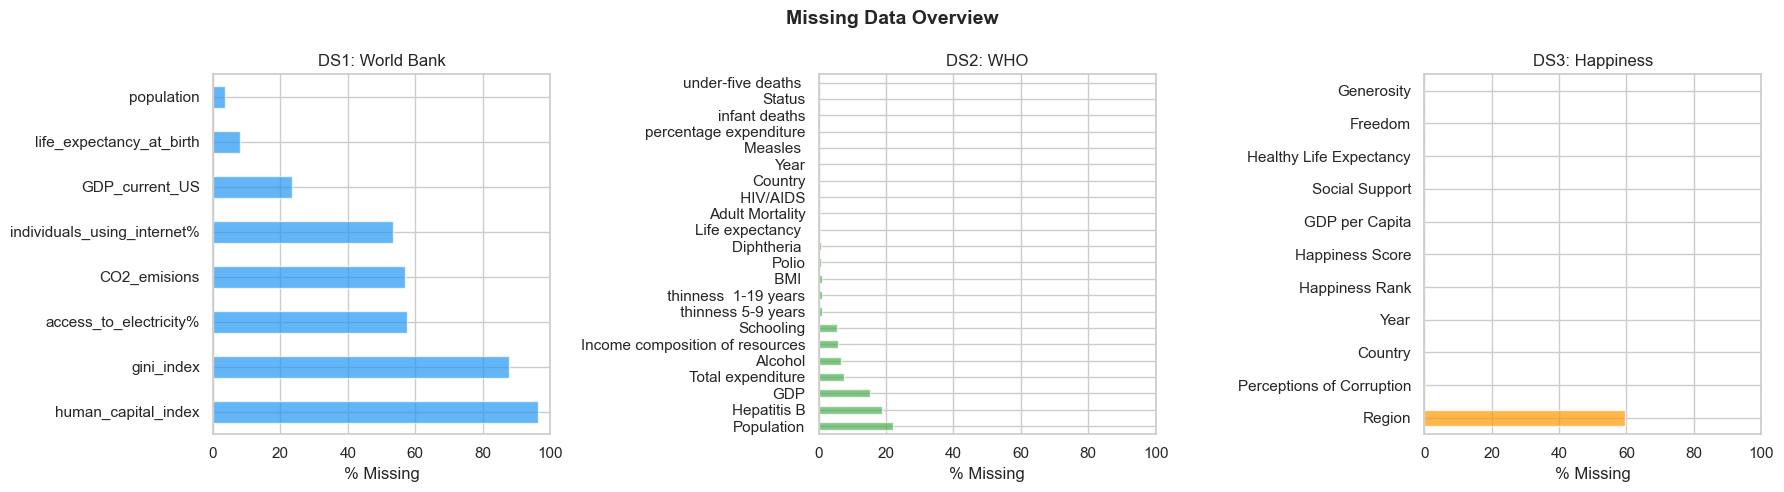

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# DS1
(df_wb[key_wb_cols].isnull().mean()*100).sort_values(ascending=False).plot.barh(ax=axes[0], color='#2196F3', alpha=0.7)
axes[0].set_xlabel('% Missing'); axes[0].set_title('DS1: World Bank'); axes[0].set_xlim(0, 100)

# DS2
(df_who.isnull().mean()*100).sort_values(ascending=False).plot.barh(ax=axes[1], color='#4CAF50', alpha=0.7)
axes[1].set_xlabel('% Missing'); axes[1].set_title('DS2: WHO'); axes[1].set_xlim(0, 100)

# DS3
(df_happiness.isnull().mean()*100).sort_values(ascending=False).plot.barh(ax=axes[2], color='#FF9800', alpha=0.7)
axes[2].set_xlabel('% Missing'); axes[2].set_title('DS3: Happiness'); axes[2].set_xlim(0, 100)

plt.suptitle('Missing Data Overview', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Section 7: Temporal Alignment ##
**Professor Feedback:** Dataset 3's temporal coverage must be aligned with other datasets.

DS1 (World Bank): 1960 - 2023 (64 years)
DS2 (WHO):        2000 - 2015 (16 years)
DS3 (Happiness):  2015 - 2019 (5 years)

All 3 overlap: [np.int64(2015)]
DS1+DS3 overlap: [np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019)]


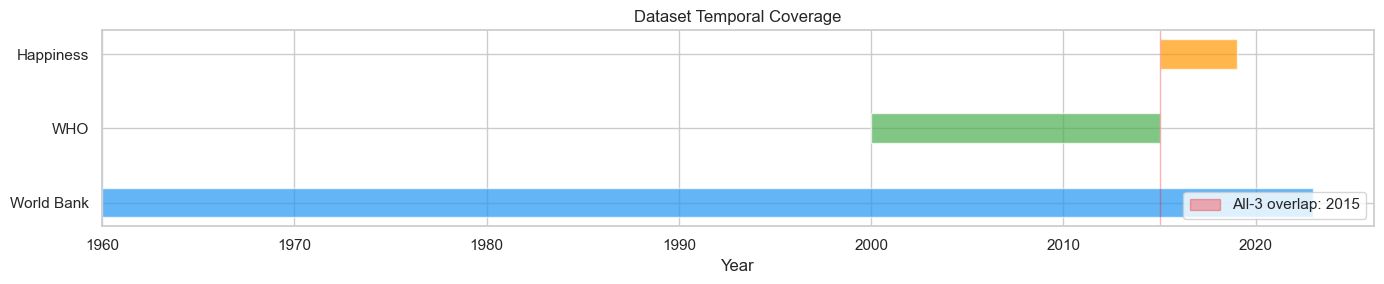


RECOMMENDATION:
  All 3 datasets -> use 2015
  DS1 + DS3 -> use 2015-2019
  DS1 trend lines -> use full 1960-2023


In [15]:
ds1_years = sorted(df_wb['Year'].dropna().unique().astype(int))
ds2_years = sorted(df_who['Year'].dropna().unique().astype(int))
ds3_years = sorted(df_happiness['Year'].dropna().unique().astype(int))

print(f"DS1 (World Bank): {ds1_years[0]} - {ds1_years[-1]} ({len(ds1_years)} years)")
print(f"DS2 (WHO):        {ds2_years[0]} - {ds2_years[-1]} ({len(ds2_years)} years)")
print(f"DS3 (Happiness):  {ds3_years[0]} - {ds3_years[-1]} ({len(ds3_years)} years)")

all_three = sorted(set(ds1_years) & set(ds2_years) & set(ds3_years))
ds1_ds3 = sorted(set(ds1_years) & set(ds3_years))
print(f"\nAll 3 overlap: {all_three}")
print(f"DS1+DS3 overlap: {ds1_ds3}")

fig, ax = plt.subplots(figsize=(14, 3))
ax.barh('World Bank', ds1_years[-1]-ds1_years[0], left=ds1_years[0], color='#2196F3', alpha=0.7, height=0.4)
ax.barh('WHO', ds2_years[-1]-ds2_years[0], left=ds2_years[0], color='#4CAF50', alpha=0.7, height=0.4)
ax.barh('Happiness', ds3_years[-1]-ds3_years[0], left=ds3_years[0], color='#FF9800', alpha=0.7, height=0.4)
ax.axvspan(min(all_three), max(all_three), alpha=0.3, color='red', label=f'All-3 overlap: {all_three[0]}')
ax.set_xlabel('Year'); ax.set_title('Dataset Temporal Coverage'); ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

print("\nRECOMMENDATION:")
print("  All 3 datasets -> use 2015")
print("  DS1 + DS3 -> use 2015-2019")
print("  DS1 trend lines -> use full 1960-2023")

## Section 8: Distribution of Numerical Features

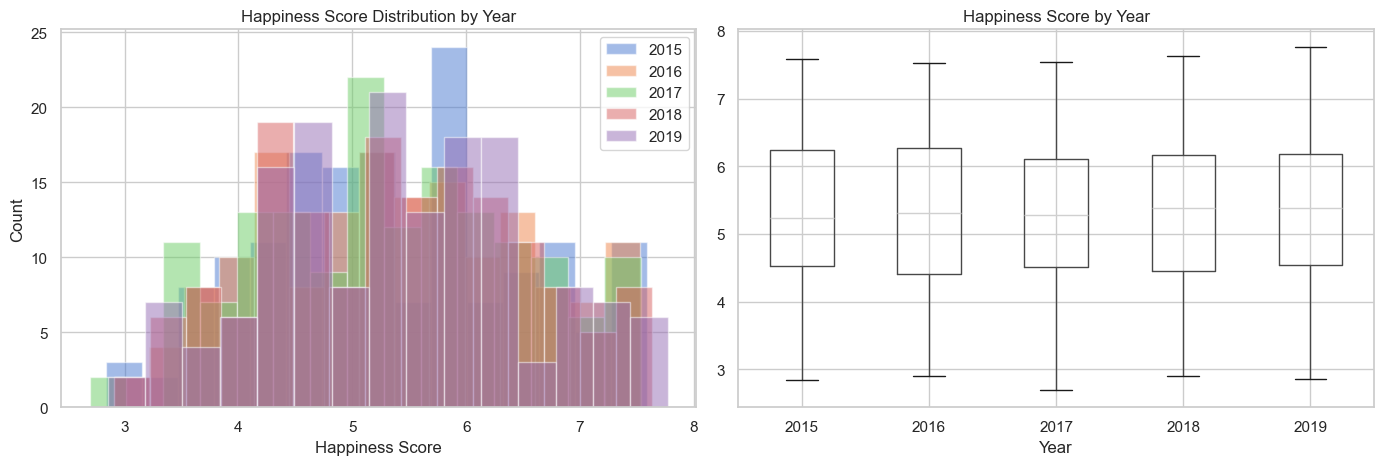

In [16]:
# Happiness Score distribution by year
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for yr in sorted(df_happiness['Year'].unique()):
    axes[0].hist(df_happiness[df_happiness['Year']==yr]['Happiness Score'], bins=15, alpha=0.5, label=str(int(yr)))
axes[0].set_xlabel('Happiness Score'); axes[0].set_ylabel('Count')
axes[0].set_title('Happiness Score Distribution by Year'); axes[0].legend()
df_happiness.boxplot(column='Happiness Score', by='Year', ax=axes[1])
axes[1].set_title('Happiness Score by Year'); plt.suptitle('')
plt.tight_layout(); plt.show()

## Section 9: Correlation Heatmap

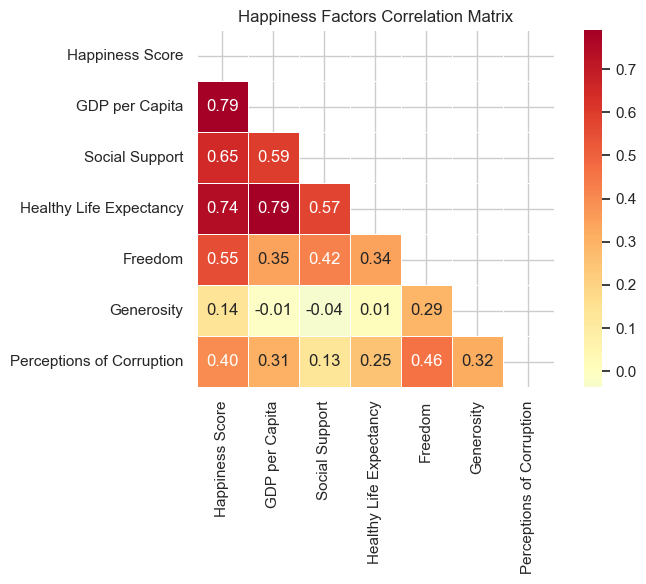

Key correlations with Happiness Score:
  GDP per Capita: 0.790
  Social Support: 0.651
  Healthy Life Expectancy: 0.743
  Freedom: 0.553
  Generosity: 0.138
  Perceptions of Corruption: 0.398


In [17]:
hap_num = df_happiness[['Happiness Score','GDP per Capita','Social Support',
    'Healthy Life Expectancy','Freedom','Generosity','Perceptions of Corruption']].dropna()
fig, ax = plt.subplots(figsize=(8, 6))
corr = hap_num.corr()
sns.heatmap(corr, mask=np.triu(np.ones_like(corr, dtype=bool)), annot=True, fmt='.2f',
            cmap='RdYlBu_r', center=0, square=True, linewidths=0.5, ax=ax)
ax.set_title('Happiness Factors Correlation Matrix')
plt.tight_layout(); plt.show()

print("Key correlations with Happiness Score:")
for col in corr.columns:
    if col != 'Happiness Score':
        print(f"  {col}: {corr.loc['Happiness Score', col]:.3f}")

## Section 10: GDP vs Happiness Scatter Plot (2015)

Matched countries: 135


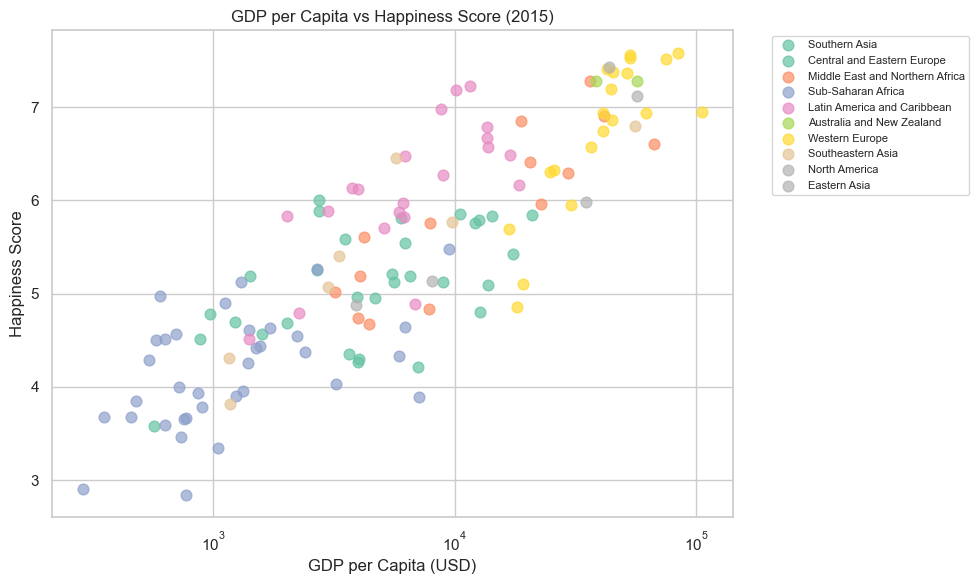

In [18]:
# Compute GDP per capita from GDP / population
wb_2015 = df_wb[df_wb['Year']==2015][['Country','GDP_current_US','population']].dropna()
wb_2015['gdp_per_capita'] = wb_2015['GDP_current_US'] / wb_2015['population']
hap_2015 = df_happiness[df_happiness['Year']==2015][['Country','Happiness Score','Region']].dropna()
m2015 = pd.merge(wb_2015, hap_2015, on='Country', how='inner')
print(f"Matched countries: {len(m2015)}")

fig, ax = plt.subplots(figsize=(10, 6))
for region, color in zip(m2015['Region'].unique(), plt.cm.Set2(np.linspace(0,1,len(m2015['Region'].unique())))):
    sub = m2015[m2015['Region']==region]
    ax.scatter(sub['gdp_per_capita'], sub['Happiness Score'], label=region, alpha=0.7, s=60, color=color)
ax.set_xlabel('GDP per Capita (USD)'); ax.set_ylabel('Happiness Score')
ax.set_title('GDP per Capita vs Happiness Score (2015)'); ax.set_xscale('log')
ax.legend(bbox_to_anchor=(1.05,1), loc='upper left', fontsize=8)
plt.tight_layout(); plt.show()

## Section 11: Life Expectancy - Top & Bottom Countries

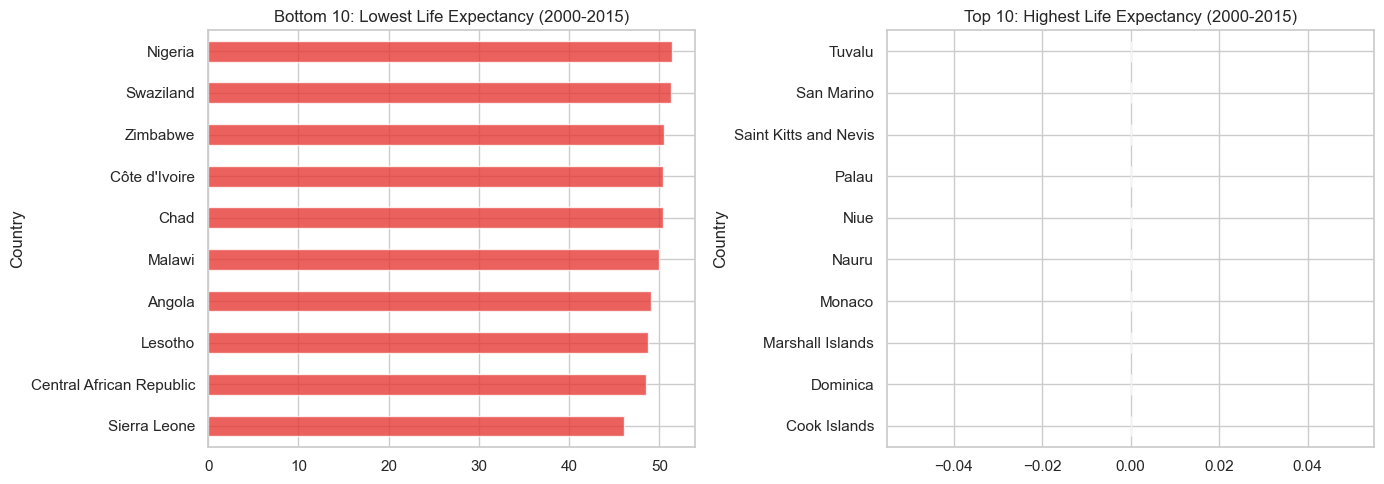

In [19]:
who_avg = df_who.groupby('Country')['Life expectancy '].mean().sort_values()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
who_avg.head(10).plot.barh(ax=axes[0], color='#E53935', alpha=0.8)
axes[0].set_title('Bottom 10: Lowest Life Expectancy (2000-2015)')
who_avg.tail(10).plot.barh(ax=axes[1], color='#43A047', alpha=0.8)
axes[1].set_title('Top 10: Highest Life Expectancy (2000-2015)')
plt.tight_layout(); plt.show()

## Section 12: World Bank Global Trends (1960-2023)

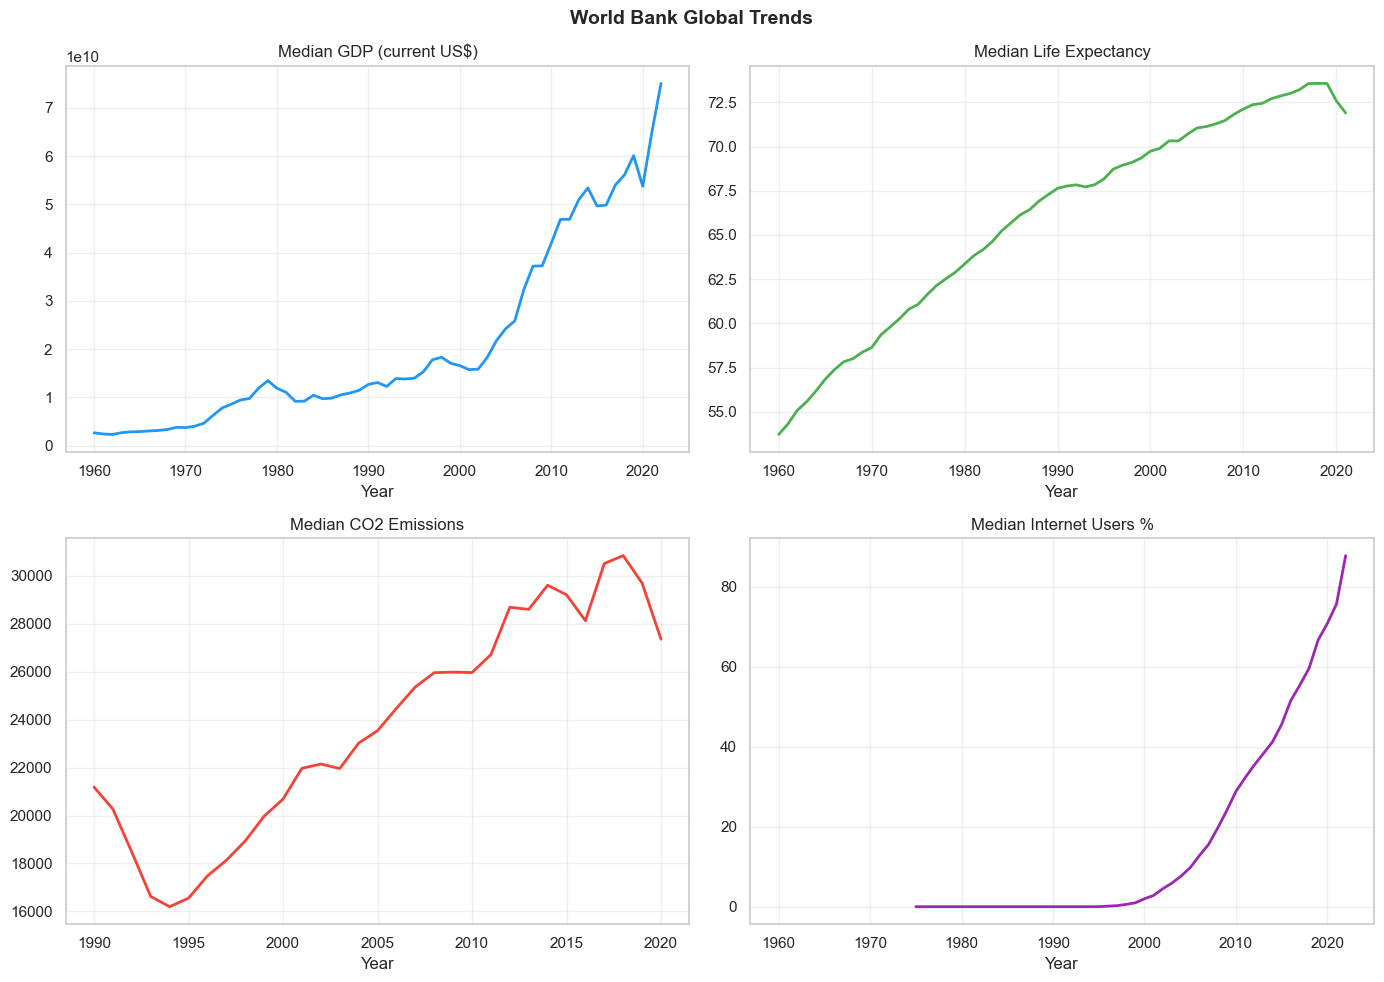

In [20]:
wb_global = df_wb.groupby('Year').agg({
    'GDP_current_US': 'median', 'life_expectancy_at_birth': 'median',
    'CO2_emisions': 'median', 'individuals_using_internet%': 'median'
}).dropna(how='all')

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, col, color, title in zip(axes.flat,
    ['GDP_current_US','life_expectancy_at_birth','CO2_emisions','individuals_using_internet%'],
    ['#2196F3','#4CAF50','#F44336','#9C27B0'],
    ['Median GDP (current US$)','Median Life Expectancy','Median CO2 Emissions','Median Internet Users %']):
    if col in wb_global.columns:
        ax.plot(wb_global.index, wb_global[col], color=color, linewidth=2)
    ax.set_title(title); ax.set_xlabel('Year'); ax.grid(alpha=0.3)
plt.suptitle('World Bank Global Trends', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

## Section 13: Outlier Detection with Box Plots

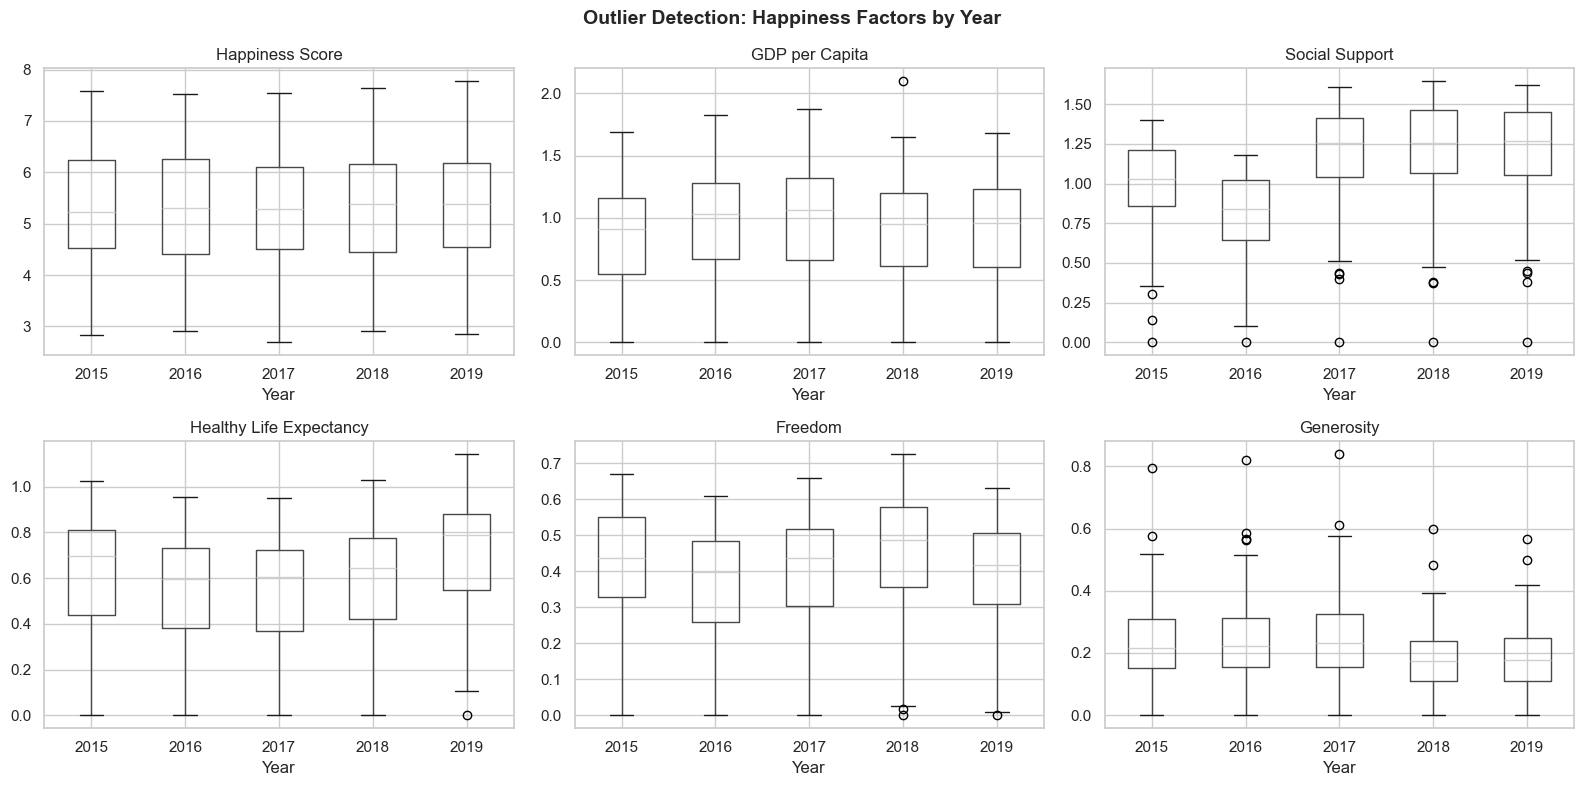

In [21]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
box_cols = ['Happiness Score','GDP per Capita','Social Support','Healthy Life Expectancy','Freedom','Generosity']
for ax, col in zip(axes.flat, box_cols):
    df_happiness.boxplot(column=col, by='Year', ax=ax)
    ax.set_title(col); ax.set_xlabel('Year')
plt.suptitle('Outlier Detection: Happiness Factors by Year', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

## Section 14: Pairwise Relationships (Happiness Factors)

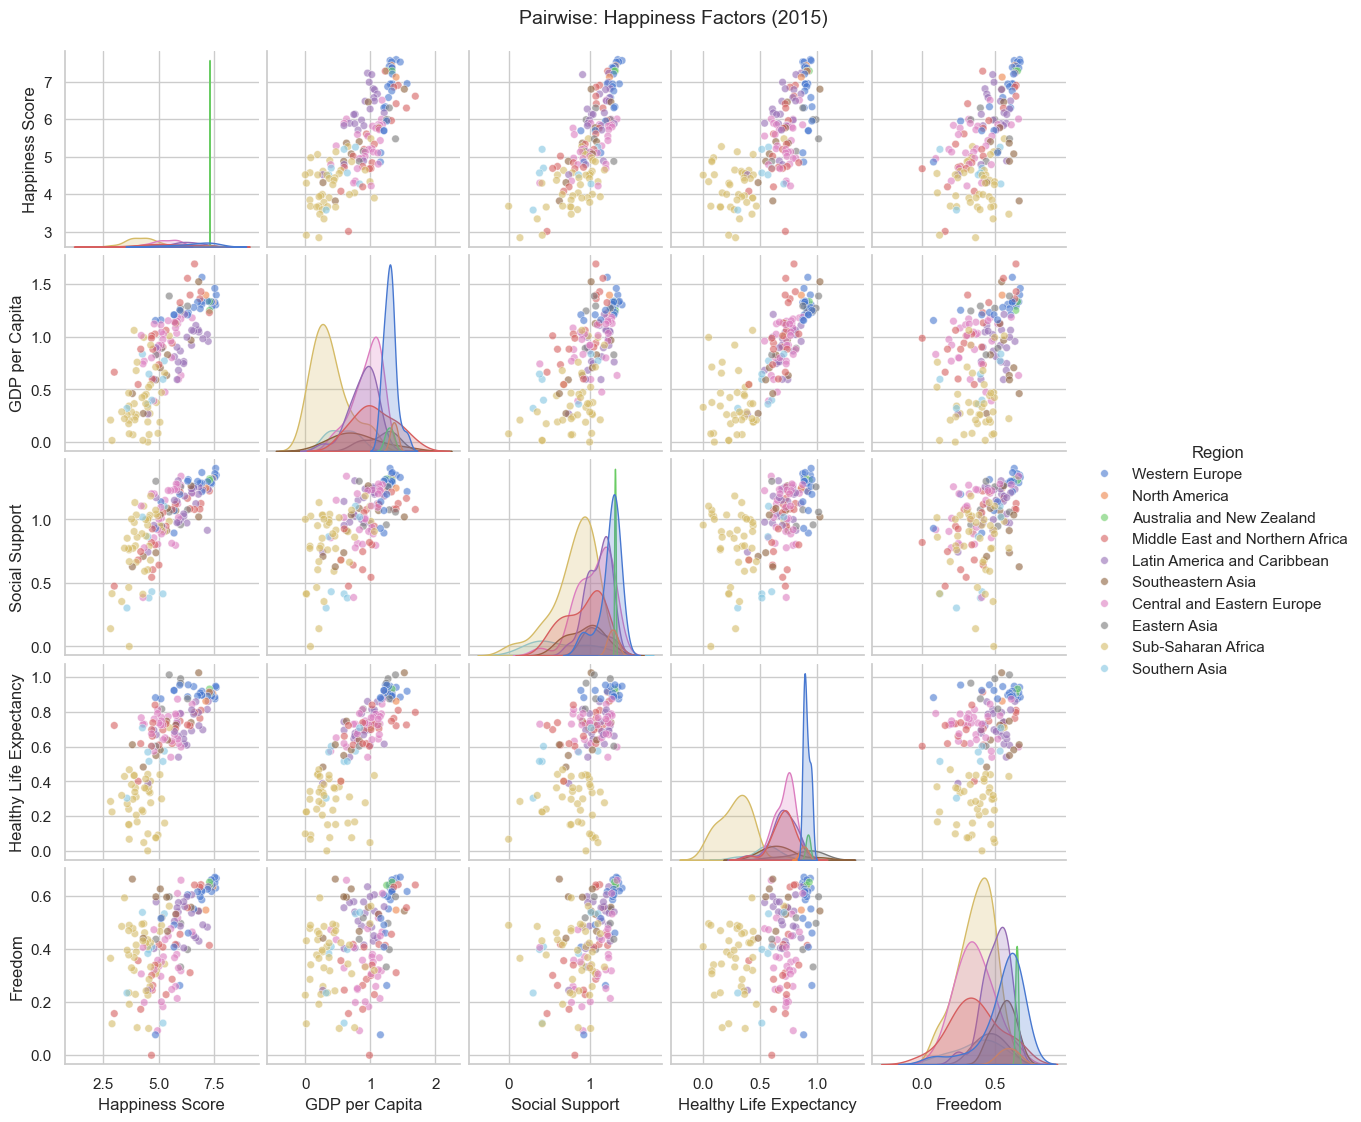

In [16]:
# Pairplot for 2015 happiness data with region coloring
hap_2015_pair = df_happiness[df_happiness['Year']==2015][['Happiness Score','GDP per Capita',
    'Social Support','Healthy Life Expectancy','Freedom','Region']].dropna()
sns.pairplot(hap_2015_pair, hue='Region', height=2.2, plot_kws={'alpha':0.6, 's':30})
plt.suptitle('Pairwise: Happiness Factors (2015)', y=1.02, fontsize=14)
plt.show()

## Section 15: Country Coverage & Overlap

DS1: 274 | DS2: 193 | DS3: 170 | All 3: 134


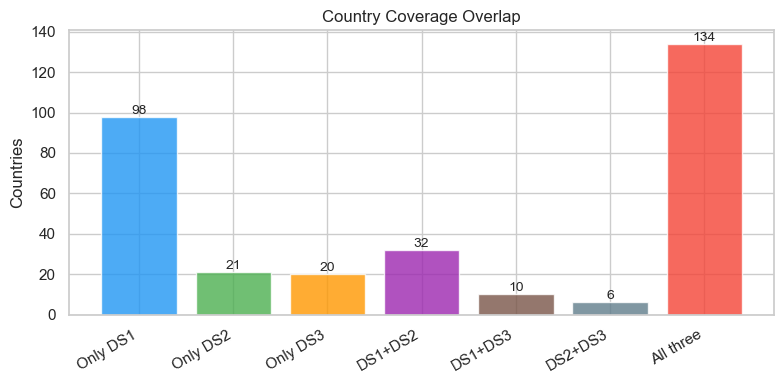

In [17]:
ds1_c = set(df_wb['Country'].dropna().str.strip())
ds2_c = set(df_who['Country'].dropna().str.strip())
ds3_c = set(df_happiness['Country'].dropna().str.strip())
all_c = ds1_c & ds2_c & ds3_c

print(f"DS1: {len(ds1_c)} | DS2: {len(ds2_c)} | DS3: {len(ds3_c)} | All 3: {len(all_c)}")

fig, ax = plt.subplots(figsize=(8, 4))
data = {
    'Only DS1': len(ds1_c - ds2_c - ds3_c), 'Only DS2': len(ds2_c - ds1_c - ds3_c),
    'Only DS3': len(ds3_c - ds1_c - ds2_c), 'DS1+DS2': len((ds1_c & ds2_c) - ds3_c),
    'DS1+DS3': len((ds1_c & ds3_c) - ds2_c), 'DS2+DS3': len((ds2_c & ds3_c) - ds1_c),
    'All three': len(all_c),
}
bars = ax.bar(data.keys(), data.values(), color=['#2196F3','#4CAF50','#FF9800','#9C27B0','#795548','#607D8B','#F44336'], alpha=0.8)
ax.bar_label(bars, fontsize=10)
ax.set_ylabel('Countries'); ax.set_title('Country Coverage Overlap')
plt.xticks(rotation=30, ha='right'); plt.tight_layout(); plt.show()

## Section 16: Summary & Key Findings

| Merge | Years | Countries | Use Case |
|-------|-------|-----------|----------|
| DS1 + DS3 | 2015-2019 | ~157 | Main scatter/bar/radar charts |
| All 3 (DS1+DS2+DS3) | 2015 | ~145 | Full well-being snapshot with health data |
| DS1 only | 1990-2023 | ~274 | Long-range trend line charts |

**Key Insights:**
- **GDP vs Happiness**: Strong log-linear (r=0.790) - diminishing returns above ~$30K
- **Life Expectancy vs Happiness**: r=0.743
- **Social Support**: r=0.651 
- **Generosity**: Weakest predictor (r=0.138)
- **Life Expectancy gap**: ~30 years between top and bottom countries
- **Clean CSV data exported to `data/` folder** (already done via run_eda.py)